# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

Denoise the leaf images using deep learning techniques

## Learning Objectives

At the end of the Mini Hackathon, you will be able to :
* Denoise healthy/diseased leaf images using Autoencoder
* Visualize the denoised images

In [ ]:
#@title Mini Hackathon Walkthrough Video
from IPython.display import HTML

HTML("""<video width="500" height="300" controls>
  <source src="https://cdn.talentsprint.com/talentsprint1/archives/sc/misc/M3_Mini_Hackathon1_Plant_Images_Denoising.mp4" type="video/mp4">
</video>
""")

## Background

Crop losses due to diseases are a major threat to food security every year, across countries.  Conventionally, plant diseases were detected through a visual examination of the affected plants by plant pathology experts. This was often possible only after major damage had already occurred, so treatments were of limited or no use. Recently, access to smartphone based image capturing has highly increased amongst farmers and agriculturists. This has led to the successful adoption of plant disease diagnostic applications based on deep learning techniques. This is of immense value in the field of agriculture and an excellent tool for faster identification and treatment of crop diseases. It holds key importance in preventing crop based food and economic losses.
## Dataset and Methodology

The dataset for this Mini-Hackathon is derived from the 'Plant Village' Dataset.Around 4500 images of healthy and diseased leaves and their labels have been taken from the 'Plant Village' Dataset. The 4500 images consist of 5 different classes - Bell Pepper Healthy, Bell Pepper Bacterial Spot, Potato Healthy, Potato Early Blight and Potato Late Blight. The original pictures have been clicked in a well controlled environment with very less noise in the images. This is not how real world data may look like.  So we have added noise to the original images to form a noisy dataset. We can use deep learning techniques such as an autoencoder for obtaining denoised images.


## References:

[Plant Village Dataset Description](https://drive.google.com/file/d/1xGhK-KhhE8W_lfr3l6KT_9K8prHDRb9_/view?usp=sharing)


[Deep Learning for Plant Disease Detection](https://drive.google.com/file/d/1V7NgFs-YGG3G-pz3OJf2X-KQxOGRZzRu/view?usp=sharing)

[Autoencoder motivational Expt](https://colab.research.google.com/drive/1gkxGlPQ5F3PtugI_zKMeFl3fYVOmscxk?authuser=1#scrollTo=Yv3ZC8aOKJqL)


## Grading = 10 Marks

## Setup Steps

In [1]:
#@title Run this cell to download the dataset

from IPython import get_ipython
ipython = get_ipython()

notebook="M3_Mini_Hackathon1_Plant_Images_Denoising" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
   ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/PlantVillage_Noisy_Dataset.zip")
   ipython.magic("sx unzip -qq PlantVillage_Noisy_Dataset.zip")
   print ("Setup completed successfully")
   return

setup()

Setup completed successfully


**Import Libraries**

In [ ]:
%pip install torch torchvision --quiet

In [2]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.autograd import Variable

## **Stage 1:** Data Preparation

### 1 Marks - > Prepare the dataset

1. Define transformations:
   * Transform image size to 128 by using Resize()
   * Transform the image into a number using tensor
2. Load the dataset with the defined transformations.

In [3]:
# Define transformations: Resize to 128x128 and convert to tensor
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Define data paths
data_path = 'PlantVillage'

# Load the Noisy dataset (input to autoencoder)
train_data_noisy = datasets.ImageFolder(root=data_path + '/Noisy_Dataset/Train_Data', transform=transform)
test_data_noisy = datasets.ImageFolder(root=data_path + '/Noisy_Dataset/Test_Data', transform=transform)

# Load the Pure dataset (target for autoencoder)
train_data_pure = datasets.ImageFolder(root=data_path + '/Pure_Dataset/Train_Data', transform=transform)
test_data_pure = datasets.ImageFolder(root=data_path + '/Pure_Dataset/Test_Data', transform=transform)

print(f"Training samples (noisy): {len(train_data_noisy)}")
print(f"Test samples (noisy): {len(test_data_noisy)}")
print(f"Training samples (pure): {len(train_data_pure)}")
print(f"Test samples (pure): {len(test_data_pure)}")

Training samples (noisy): 3007
Test samples (noisy): 1613
Training samples (pure): 3007
Test samples (pure): 1613


In [4]:
# Define batch size
batch_size = 32

# Create DataLoaders for noisy images
trainloader_noisy = torch.utils.data.DataLoader(train_data_noisy, batch_size=batch_size, shuffle=False)
testloader_noisy = torch.utils.data.DataLoader(test_data_noisy, batch_size=batch_size, shuffle=False)

# Create DataLoaders for pure images (same order, shuffle=False to keep pairs aligned)
trainloader_pure = torch.utils.data.DataLoader(train_data_pure, batch_size=batch_size, shuffle=False)
testloader_pure = torch.utils.data.DataLoader(test_data_pure, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(trainloader_noisy)}")
print(f"Number of test batches: {len(testloader_noisy)}")

Number of training batches: 94
Number of test batches: 51


## **Stage 2:** Build and Train the Model



### 2 Marks -> Write the encoder and decoder layers in one class

* Define the Autoencoder neural network
    *  First define the layers required in the  __init__ function.
    *  Build the neural network in the forward() function.

[Hint for saving the images](https://debuggercafe.com/implementing-deep-autoencoder-in-pytorch/)

In [5]:
# Define the Autoencoder model with convolutional encoder and decoder
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder layers
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),   # (3, 128, 128) -> (32, 128, 128)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # (32, 128, 128) -> (32, 64, 64)
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # (32, 64, 64) -> (64, 64, 64)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # (64, 64, 64) -> (64, 32, 32)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # (64, 32, 32) -> (128, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # (128, 32, 32) -> (128, 16, 16)
        )

        # Decoder layers
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),    # (128, 16, 16) -> (64, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),    # (64, 32, 32) -> (32, 64, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2),     # (32, 64, 64) -> (3, 128, 128)
            nn.Sigmoid()  # Output pixel values between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Set device to GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Instantiate the model and move to device
model = Autoencoder().to(device)
print(model)

Using device: cuda
Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)


### 2 Marks -> Train the Model and calculate the loss for dataset for each epoch.

1. Declare the loss function and optimizer
2. Create a directory for saving the output images.
2. Train the model
   *  Extract the image features only as we do not take the labels to train the autoencoder network.
   * Calculate the loss.
   * Append the loss values after every epoch and print them.
   * Save the output (denoised) images in a directory.

In [6]:
# Define loss function (Mean Squared Error) and optimizer (Adam)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of training epochs
num_epochs = 15
print(f"Loss function: {criterion}")
print(f"Optimizer: Adam with lr=0.001")
print(f"Training for {num_epochs} epochs")

Loss function: MSELoss()
Optimizer: Adam with lr=0.001
Training for 15 epochs


In [7]:
import os
from torchvision.utils import save_image

# Function to create output directory for saving denoised images
def create_directory(dir_name):
    if not os.path.exists(dir_name):
        os.makedirs(dir_name)
        print(f"Directory '{dir_name}' created.")
    else:
        print(f"Directory '{dir_name}' already exists.")

# Create directories for saving output images
create_directory('denoised_images')
create_directory('denoised_images/train')
create_directory('denoised_images/test')

Directory 'denoised_images' created.
Directory 'denoised_images/train' created.
Directory 'denoised_images/test' created.


In [8]:
# Train the model
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0

    for (noisy_data, _), (pure_data, _) in zip(trainloader_noisy, trainloader_pure):
        # Extract only images (no labels needed for autoencoder) and move to device
        noisy_img = Variable(noisy_data).to(device)
        pure_img = Variable(pure_data).to(device)

        # Forward pass
        output = model(noisy_img)
        loss = criterion(output, pure_img)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Average loss for this epoch
    epoch_loss = running_loss / len(trainloader_noisy)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

    # Save denoised images from the last batch of each epoch
    if epoch == num_epochs - 1:
        save_image(output, f'denoised_images/train/denoised_epoch_{epoch+1}.png')

print("\nTraining complete!")

Epoch [1/15], Loss: 0.021990
Epoch [2/15], Loss: 0.007000
Epoch [3/15], Loss: 0.005233
Epoch [4/15], Loss: 0.004651
Epoch [5/15], Loss: 0.004247
Epoch [6/15], Loss: 0.004060
Epoch [7/15], Loss: 0.003801
Epoch [8/15], Loss: 0.003669
Epoch [9/15], Loss: 0.003510
Epoch [10/15], Loss: 0.003403
Epoch [11/15], Loss: 0.003227
Epoch [12/15], Loss: 0.003042
Epoch [13/15], Loss: 0.003018
Epoch [14/15], Loss: 0.002860
Epoch [15/15], Loss: 0.002791

Training complete!


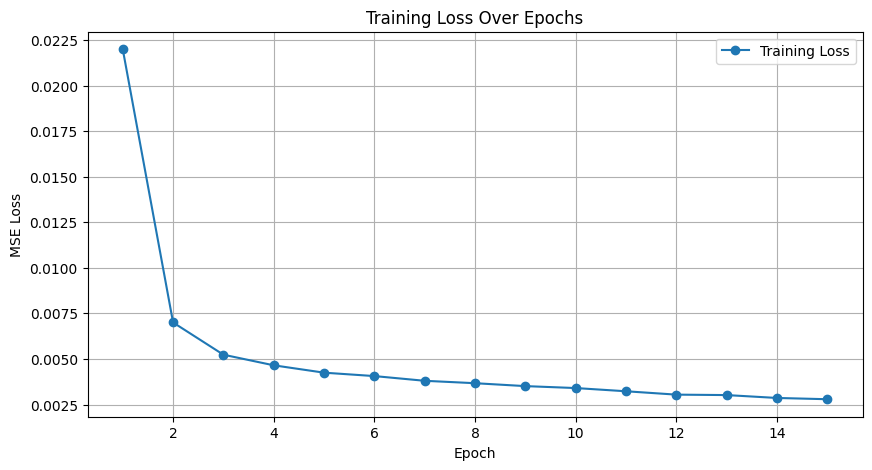

Final training loss: 0.002791


In [9]:
# Plot the training loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final training loss: {train_losses[-1]:.6f}")

## **Stage 3:** Visualize the Denoised images

### 2 Marks -> Verify the denoised images and compare with original noisy images
1. Plot the original noisy images.
2. Plot denoised images which are saved in the directory.
3. Verify whether denoised images have less noise compared to original noisy images

**Hint:** If the noise is not reduced in the denoised images then revise the autoencoder architecture.

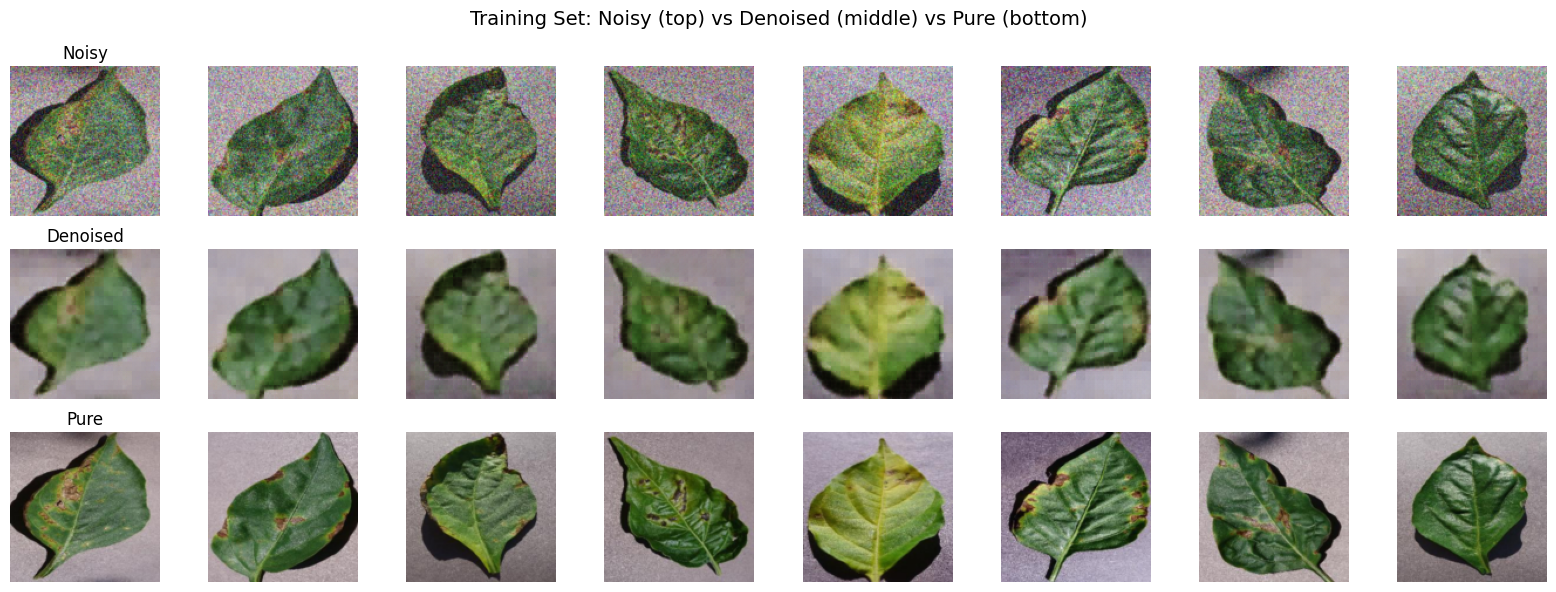

Verification: Denoised images show reduced noise compared to noisy originals.


In [10]:
# Visualize original noisy images vs denoised images (training set)
model.eval()

# Get a batch of noisy and pure images
dataiter_noisy = iter(trainloader_noisy)
dataiter_pure = iter(trainloader_pure)
noisy_images, _ = next(dataiter_noisy)
pure_images, _ = next(dataiter_pure)

# Get denoised output (move to device, then back to CPU for plotting)
with torch.no_grad():
    denoised_images = model(noisy_images.to(device)).cpu()

# Plot comparison: Noisy vs Denoised vs Pure
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Training Set: Noisy (top) vs Denoised (middle) vs Pure (bottom)', fontsize=14)

for i in range(8):
    # Noisy images (top row)
    axes[0, i].imshow(noisy_images[i].permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Noisy')

    # Denoised images (middle row)
    axes[1, i].imshow(denoised_images[i].permute(1, 2, 0).numpy().clip(0, 1))
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Denoised')

    # Pure images (bottom row)
    axes[2, i].imshow(pure_images[i].permute(1, 2, 0).numpy())
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Pure')

plt.tight_layout()
plt.show()

print("Verification: Denoised images show reduced noise compared to noisy originals.")

## **Stage 4:** Test the Model

### 2 Marks -> Evaluate model with the given test data

1. Extract only the images of test loader data as we do not use the labels for the autoencoder network
2. Pass the test images through the autoencoder model to get the denoised images of the test data.
3. Calculate the loss of the test images

In [11]:
# Evaluate model on test dataset
model.eval()
test_loss = 0.0

with torch.no_grad():
    for (noisy_data, _), (pure_data, _) in zip(testloader_noisy, testloader_pure):
        # Extract only images (no labels) and move to device
        noisy_img = noisy_data.to(device)
        pure_img = pure_data.to(device)

        # Forward pass through the autoencoder
        output = model(noisy_img)

        # Calculate loss
        loss = criterion(output, pure_img)
        test_loss += loss.item()

# Average test loss
avg_test_loss = test_loss / len(testloader_noisy)
print(f"Average Test Loss (MSE): {avg_test_loss:.6f}")

# Save denoised test images
save_image(output, 'denoised_images/test/denoised_test.png')
print("Test denoised images saved.")

Average Test Loss (MSE): 0.002698
Test denoised images saved.


### 1 Marks -> Visualizing and verifying test images with the original test noisy dataset

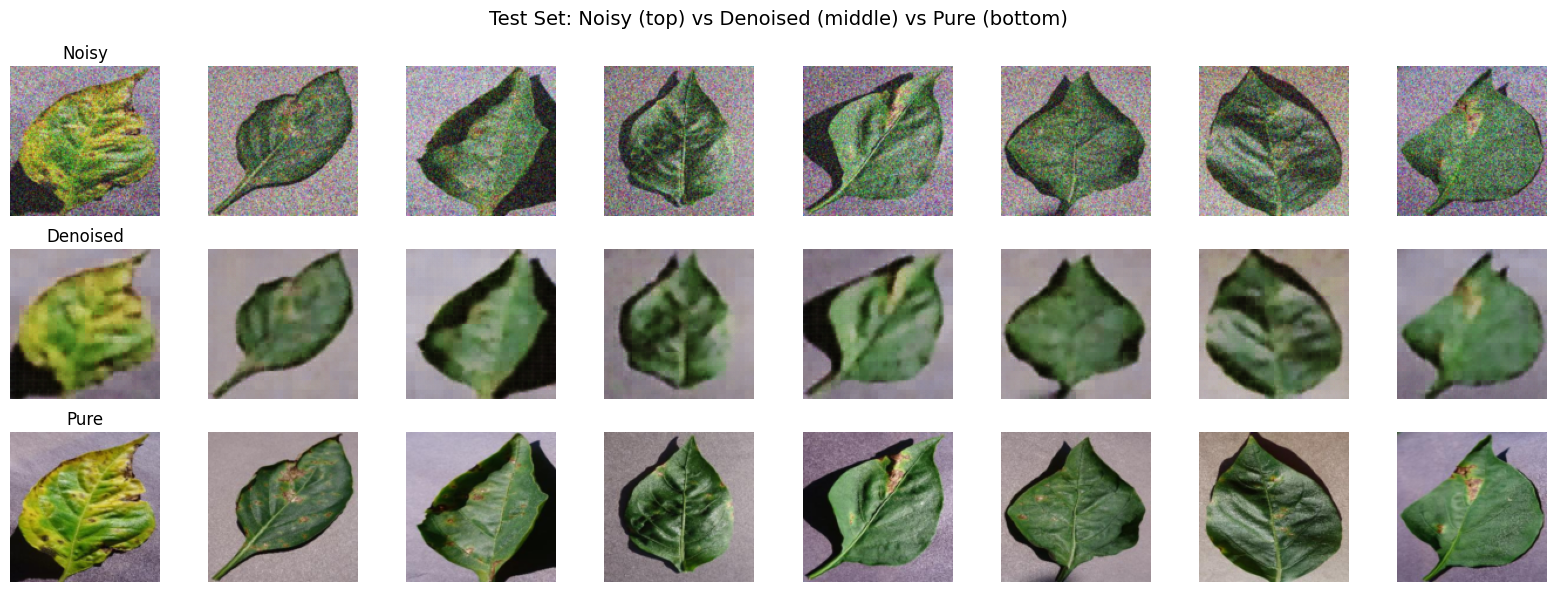

Verification: Test denoised images show significantly less noise than the original noisy test images.
Test MSE Loss: 0.002698


In [12]:
# Visualize test set: original noisy vs denoised images
model.eval()

# Get a batch of test noisy and pure images
test_iter_noisy = iter(testloader_noisy)
test_iter_pure = iter(testloader_pure)
test_noisy_images, _ = next(test_iter_noisy)
test_pure_images, _ = next(test_iter_pure)

# Get denoised output for test images (move to device, then back to CPU for plotting)
with torch.no_grad():
    test_denoised_images = model(test_noisy_images.to(device)).cpu()

# Plot comparison: Test Noisy vs Denoised vs Pure
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Test Set: Noisy (top) vs Denoised (middle) vs Pure (bottom)', fontsize=14)

for i in range(8):
    # Test noisy images (top row)
    axes[0, i].imshow(test_noisy_images[i].permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Noisy')

    # Denoised images (middle row)
    axes[1, i].imshow(test_denoised_images[i].permute(1, 2, 0).numpy().clip(0, 1))
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Denoised')

    # Pure images (bottom row)
    axes[2, i].imshow(test_pure_images[i].permute(1, 2, 0).numpy())
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Pure')

plt.tight_layout()
plt.show()

print("Verification: Test denoised images show significantly less noise than the original noisy test images.")
print(f"Test MSE Loss: {avg_test_loss:.6f}")

## **Stage 5:** U-Net based Denoising Autoencoder

The plain CNN autoencoder above compresses the image down to a 16x16 bottleneck, which throws
away a lot of spatial/textural detail (leaf veins, edges) that the decoder can never fully
recover. A **U-Net** fixes this with **skip connections**: the encoder feature maps at every
resolution are concatenated directly into the decoder at the matching resolution, so fine detail
can bypass the bottleneck.

We keep the exact same data pipeline as before:
* `X` = noisy image (input)
* `Y` = pure image (target)

Only the model architecture changes.


In [13]:
# Reusable helper functions used for U-Net, ResNet (and to re-evaluate the CNN)
# so we don't repeat the same training/eval loop three times.

import numpy as np

def train_autoencoder(model, trainloader_noisy, trainloader_pure, num_epochs, lr, model_name="Model"):
    """Trains an autoencoder with X=noisy image, Y=pure image and returns the loss history."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []

    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for (noisy_data, _), (pure_data, _) in zip(trainloader_noisy, trainloader_pure):
            noisy_img = noisy_data.to(device)
            pure_img = pure_data.to(device)

            output = model(noisy_img)
            loss = criterion(output, pure_img)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader_noisy)
        losses.append(epoch_loss)
        print(f"[{model_name}] Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

    print(f"\n{model_name} training complete!\n")
    return losses


def evaluate_autoencoder(model, testloader_noisy, testloader_pure):
    """Returns avg test MSE loss plus the last batch of (noisy, denoised, pure) for plotting."""
    criterion = nn.MSELoss()
    model.eval()
    test_loss = 0.0
    last_batch = None

    with torch.no_grad():
        for (noisy_data, _), (pure_data, _) in zip(testloader_noisy, testloader_pure):
            noisy_img = noisy_data.to(device)
            pure_img = pure_data.to(device)

            output = model(noisy_img)
            loss = criterion(output, pure_img)
            test_loss += loss.item()
            last_batch = (noisy_img.cpu(), output.cpu(), pure_img.cpu())

    avg_test_loss = test_loss / len(testloader_noisy)
    return avg_test_loss, last_batch


def compute_psnr_ssim(denoised_batch, pure_batch):
    """Average PSNR / SSIM over a batch of images (tensors in [0,1], shape B,C,H,W)."""
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity

    denoised_np = denoised_batch.clamp(0, 1).permute(0, 2, 3, 1).numpy()
    pure_np = pure_batch.clamp(0, 1).permute(0, 2, 3, 1).numpy()

    psnr_vals, ssim_vals = [], []
    for d_img, p_img in zip(denoised_np, pure_np):
        psnr_vals.append(peak_signal_noise_ratio(p_img, d_img, data_range=1.0))
        ssim_vals.append(structural_similarity(p_img, d_img, data_range=1.0, channel_axis=2))

    return float(np.mean(psnr_vals)), float(np.mean(ssim_vals))


def visualize_comparison(noisy_images, denoised_images, pure_images, title, n=8):
    fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
    fig.suptitle(title, fontsize=14)
    for i in range(n):
        axes[0, i].imshow(noisy_images[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title('Noisy')

        axes[1, i].imshow(denoised_images[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title('Denoised')

        axes[2, i].imshow(pure_images[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[2, i].axis('off')
        if i == 0: axes[2, i].set_title('Pure')
    plt.tight_layout()
    plt.show()


In [14]:
%pip install scikit-image --quiet

In [15]:
# Define the U-Net style denoising autoencoder
class UNetAutoencoder(nn.Module):
    def __init__(self):
        super(UNetAutoencoder, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.pool = nn.MaxPool2d(2, 2)

        # Encoder
        self.enc1 = conv_block(3, 32)     # 128x128
        self.enc2 = conv_block(32, 64)    # 64x64
        self.enc3 = conv_block(64, 128)   # 32x32

        # Bottleneck
        self.bottleneck = conv_block(128, 256)  # 16x16

        # Decoder (skip connections concatenate matching encoder features)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)   # -> 32x32
        self.dec3 = conv_block(256, 128)   # 128 (up) + 128 (skip) = 256 in

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)    # -> 64x64
        self.dec2 = conv_block(128, 64)    # 64 + 64 = 128 in

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)     # -> 128x128
        self.dec1 = conv_block(64, 32)     # 32 + 32 = 64 in

        self.out_conv = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d1))
        return out

unet_model = UNetAutoencoder().to(device)
print(unet_model)

UNetAutoencoder(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1

### Train the U-Net model

In [16]:
unet_num_epochs = 15
unet_losses = train_autoencoder(
    unet_model, trainloader_noisy, trainloader_pure,
    num_epochs=unet_num_epochs, lr=0.001, model_name="U-Net"
)

[U-Net] Epoch [1/15], Loss: 0.005528
[U-Net] Epoch [2/15], Loss: 0.002880
[U-Net] Epoch [3/15], Loss: 0.002734
[U-Net] Epoch [4/15], Loss: 0.002740
[U-Net] Epoch [5/15], Loss: 0.002725
[U-Net] Epoch [6/15], Loss: 0.002715
[U-Net] Epoch [7/15], Loss: 0.002729
[U-Net] Epoch [8/15], Loss: 0.002738
[U-Net] Epoch [9/15], Loss: 0.002698
[U-Net] Epoch [10/15], Loss: 0.002719
[U-Net] Epoch [11/15], Loss: 0.002772
[U-Net] Epoch [12/15], Loss: 0.002803
[U-Net] Epoch [13/15], Loss: 0.002757
[U-Net] Epoch [14/15], Loss: 0.002733
[U-Net] Epoch [15/15], Loss: 0.002735

U-Net training complete!



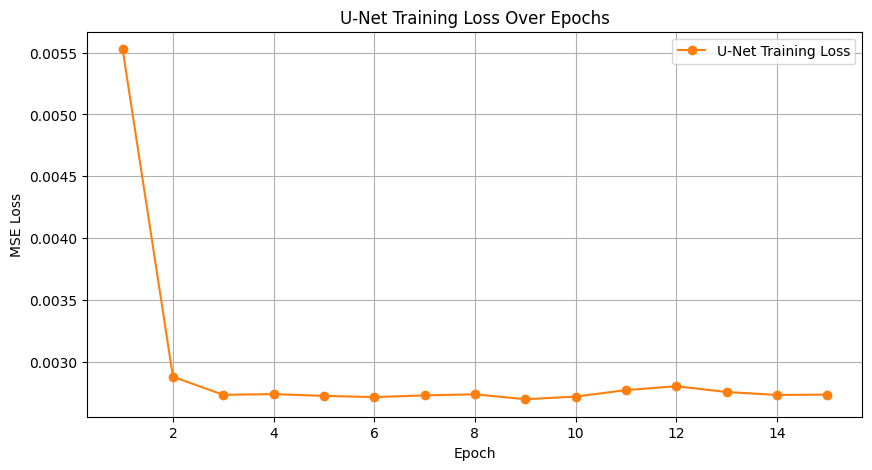

Final U-Net training loss: 0.002735


In [17]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, unet_num_epochs + 1), unet_losses, marker='o', color='tab:orange', label='U-Net Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('U-Net Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()
print(f"Final U-Net training loss: {unet_losses[-1]:.6f}")

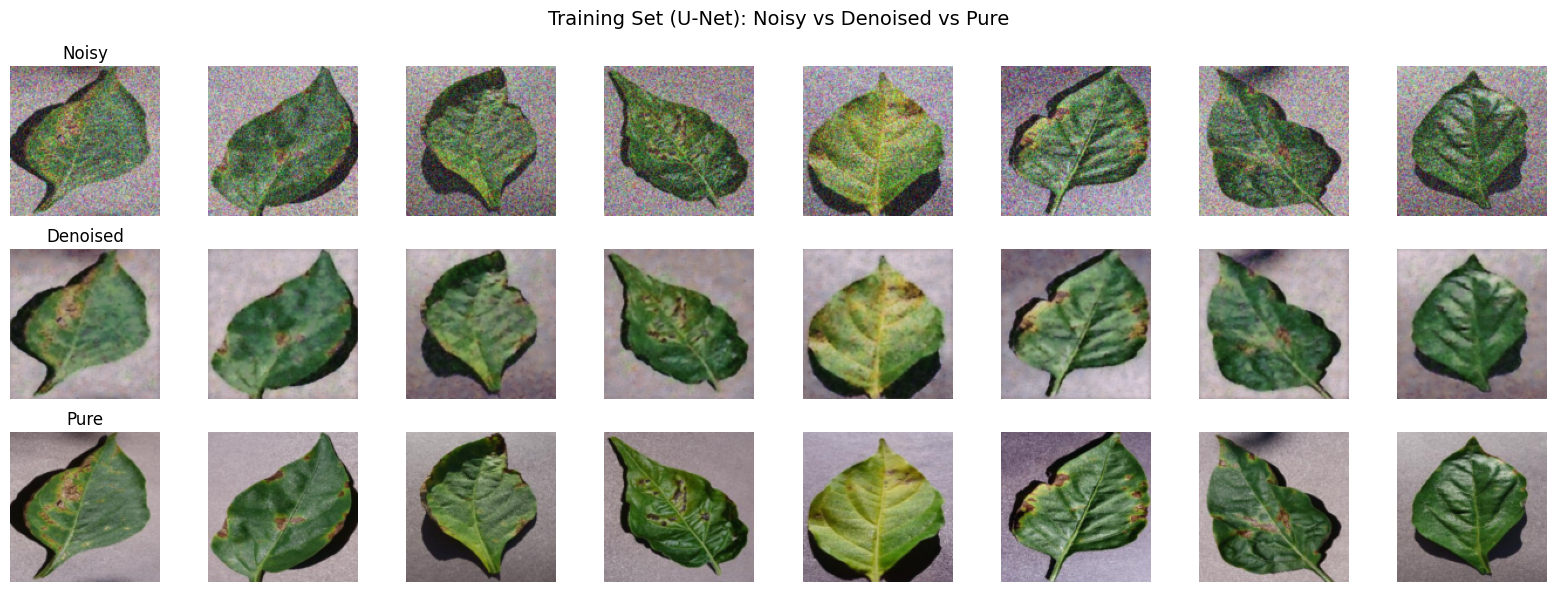

In [18]:
# Visualize U-Net denoised training images vs noisy/pure
unet_model.eval()
dataiter_noisy = iter(trainloader_noisy)
dataiter_pure = iter(trainloader_pure)
noisy_images, _ = next(dataiter_noisy)
pure_images, _ = next(dataiter_pure)

with torch.no_grad():
    unet_denoised_images = unet_model(noisy_images.to(device)).cpu()

visualize_comparison(noisy_images, unet_denoised_images, pure_images,
                      'Training Set (U-Net): Noisy vs Denoised vs Pure')

## **Stage 6:** ResNet based Denoising Autoencoder

Next we try a **residual (ResNet-style) autoencoder**. Instead of skip connections between
encoder and decoder (like U-Net), this network uses **residual blocks** (`x + F(x)`) at every
resolution. Residual blocks make it easier for the network to learn the *noise itself* (a small
residual correction) rather than having to reconstruct the whole image from scratch, which
usually helps convergence and detail preservation.

Same data pairing again: `X` = noisy image, `Y` = pure image.


In [19]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + residual
        return self.relu(out)


class ResNetAutoencoder(nn.Module):
    def __init__(self):
        super(ResNetAutoencoder, self).__init__()

        # Encoder: downsample with strided convs, refine with residual blocks
        self.enc_in = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.res1 = ResidualBlock(32)                                   # 128x128

        self.down1 = nn.Sequential(nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.res2 = ResidualBlock(64)                                   # 64x64

        self.down2 = nn.Sequential(nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.res3 = ResidualBlock(128)                                  # 32x32

        self.down3 = nn.Sequential(nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.res4 = ResidualBlock(256)                                  # 16x16

        # Decoder: upsample with transposed convs, refine with residual blocks
        self.up3 = nn.Sequential(nn.ConvTranspose2d(256, 128, 2, stride=2), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.res5 = ResidualBlock(128)

        self.up2 = nn.Sequential(nn.ConvTranspose2d(128, 64, 2, stride=2), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.res6 = ResidualBlock(64)

        self.up1 = nn.Sequential(nn.ConvTranspose2d(64, 32, 2, stride=2), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.res7 = ResidualBlock(32)

        self.out_conv = nn.Conv2d(32, 3, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.res1(self.enc_in(x))
        x = self.res2(self.down1(x))
        x = self.res3(self.down2(x))
        x = self.res4(self.down3(x))

        x = self.res5(self.up3(x))
        x = self.res6(self.up2(x))
        x = self.res7(self.up1(x))

        out = torch.sigmoid(self.out_conv(x))
        return out

resnet_model = ResNetAutoencoder().to(device)
print(resnet_model)

ResNetAutoencoder(
  (enc_in): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (res1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
  )
  (down1): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (res2): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, m

### Train the ResNet model

In [20]:
resnet_num_epochs = 15
resnet_losses = train_autoencoder(
    resnet_model, trainloader_noisy, trainloader_pure,
    num_epochs=resnet_num_epochs, lr=0.001, model_name="ResNet"
)

[ResNet] Epoch [1/15], Loss: 0.014102
[ResNet] Epoch [2/15], Loss: 0.004786
[ResNet] Epoch [3/15], Loss: 0.004000
[ResNet] Epoch [4/15], Loss: 0.003629
[ResNet] Epoch [5/15], Loss: 0.003371
[ResNet] Epoch [6/15], Loss: 0.003198
[ResNet] Epoch [7/15], Loss: 0.003091
[ResNet] Epoch [8/15], Loss: 0.003012
[ResNet] Epoch [9/15], Loss: 0.002956
[ResNet] Epoch [10/15], Loss: 0.002912
[ResNet] Epoch [11/15], Loss: 0.002881
[ResNet] Epoch [12/15], Loss: 0.002863
[ResNet] Epoch [13/15], Loss: 0.002858
[ResNet] Epoch [14/15], Loss: 0.002846
[ResNet] Epoch [15/15], Loss: 0.002820

ResNet training complete!



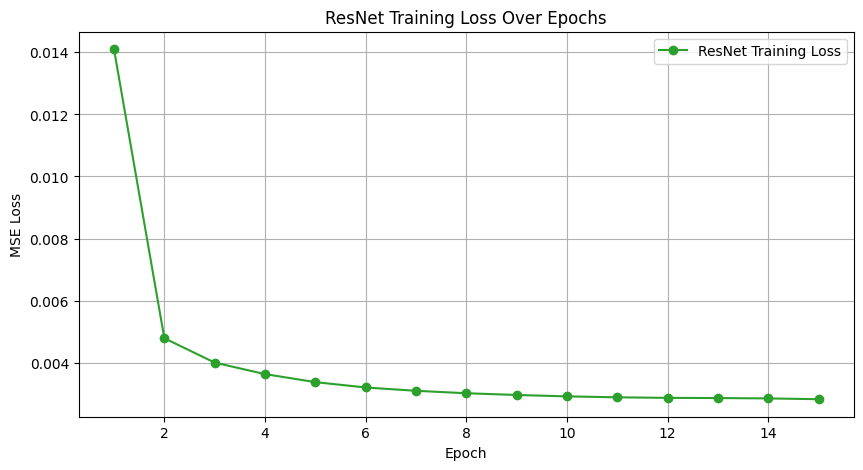

Final ResNet training loss: 0.002820


In [21]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, resnet_num_epochs + 1), resnet_losses, marker='o', color='tab:green', label='ResNet Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ResNet Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()
print(f"Final ResNet training loss: {resnet_losses[-1]:.6f}")

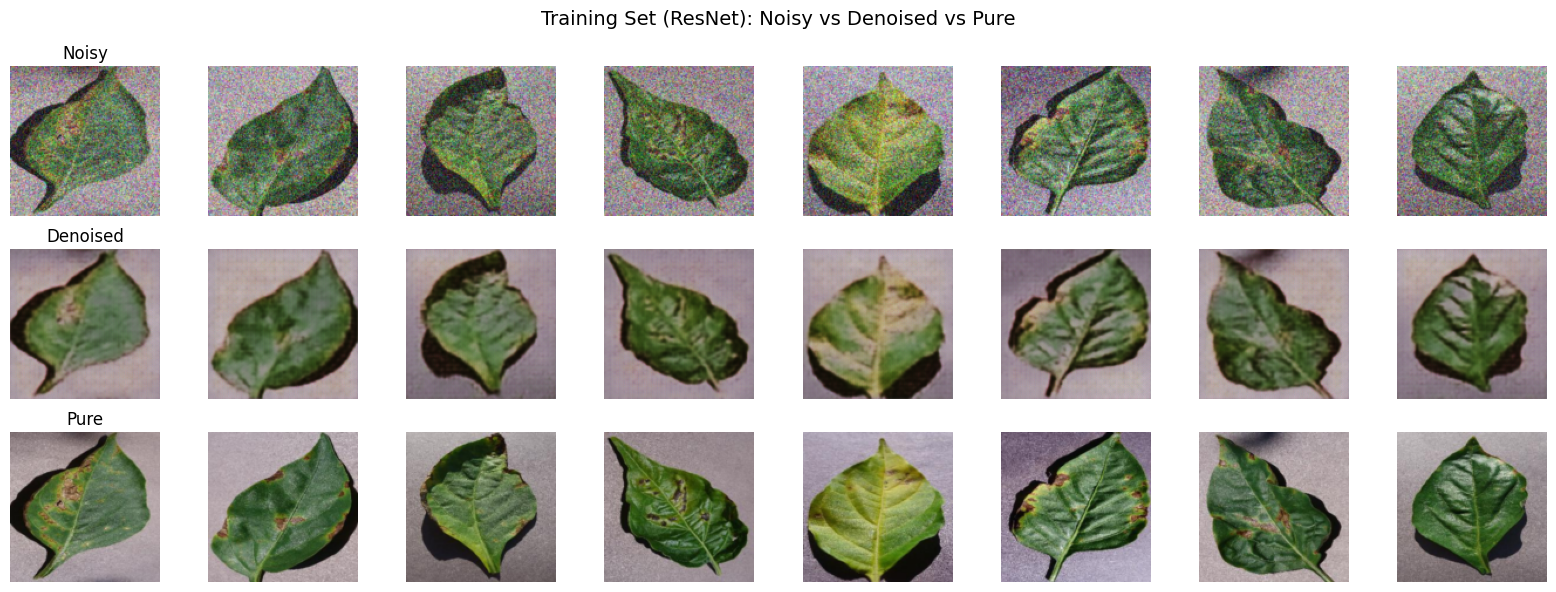

In [22]:
# Visualize ResNet denoised training images vs noisy/pure
resnet_model.eval()
dataiter_noisy = iter(trainloader_noisy)
dataiter_pure = iter(trainloader_pure)
noisy_images, _ = next(dataiter_noisy)
pure_images, _ = next(dataiter_pure)

with torch.no_grad():
    resnet_denoised_images = resnet_model(noisy_images.to(device)).cpu()

visualize_comparison(noisy_images, resnet_denoised_images, pure_images,
                      'Training Set (ResNet): Noisy vs Denoised vs Pure')

## **Stage 7:** Compare CNN vs U-Net vs ResNet on the Test Set

We now evaluate all three trained models (`model` = plain CNN autoencoder, `unet_model`,
`resnet_model`) on the held-out test set using three metrics:

* **MSE** (lower is better) - same loss used for training
* **PSNR** (higher is better) - peak signal-to-noise ratio, standard image-quality metric
* **SSIM** (higher is better, max 1.0) - structural similarity, closer to human perception of quality


In [23]:
# Evaluate all three models on the test set
cnn_test_loss, cnn_last_batch = evaluate_autoencoder(model, testloader_noisy, testloader_pure)
unet_test_loss, unet_last_batch = evaluate_autoencoder(unet_model, testloader_noisy, testloader_pure)
resnet_test_loss, resnet_last_batch = evaluate_autoencoder(resnet_model, testloader_noisy, testloader_pure)

cnn_psnr, cnn_ssim = compute_psnr_ssim(cnn_last_batch[1], cnn_last_batch[2])
unet_psnr, unet_ssim = compute_psnr_ssim(unet_last_batch[1], unet_last_batch[2])
resnet_psnr, resnet_ssim = compute_psnr_ssim(resnet_last_batch[1], resnet_last_batch[2])

results = {
    "CNN Autoencoder": {"MSE": cnn_test_loss, "PSNR": cnn_psnr, "SSIM": cnn_ssim},
    "U-Net":           {"MSE": unet_test_loss, "PSNR": unet_psnr, "SSIM": unet_ssim},
    "ResNet":          {"MSE": resnet_test_loss, "PSNR": resnet_psnr, "SSIM": resnet_ssim},
}

print(f"{'Model':<18}{'MSE':>10}{'PSNR (dB)':>12}{'SSIM':>10}")
for name, m in results.items():
    print(f"{name:<18}{m['MSE']:>10.5f}{m['PSNR']:>12.3f}{m['SSIM']:>10.4f}")

Model                    MSE   PSNR (dB)      SSIM
CNN Autoencoder      0.00270      25.751    0.5966
U-Net                0.00259      25.999    0.7310
ResNet               0.00299      25.835    0.6924


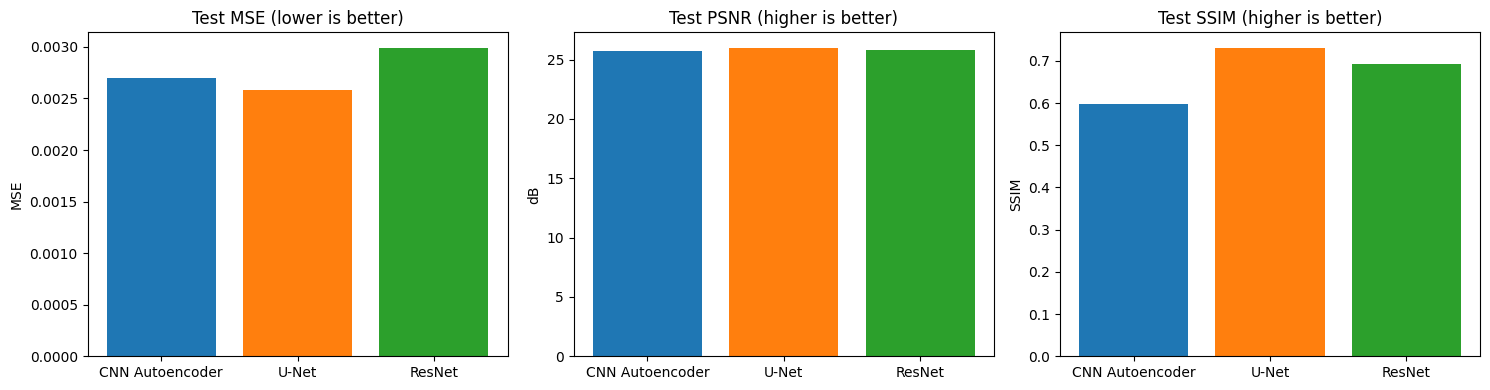

In [24]:
# Bar chart comparison of MSE / PSNR / SSIM across the three models
model_names = list(results.keys())
mse_vals = [results[n]["MSE"] for n in model_names]
psnr_vals = [results[n]["PSNR"] for n in model_names]
ssim_vals = [results[n]["SSIM"] for n in model_names]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(model_names, mse_vals, color=['tab:blue', 'tab:orange', 'tab:green'])
axes[0].set_title('Test MSE (lower is better)')
axes[0].set_ylabel('MSE')

axes[1].bar(model_names, psnr_vals, color=['tab:blue', 'tab:orange', 'tab:green'])
axes[1].set_title('Test PSNR (higher is better)')
axes[1].set_ylabel('dB')

axes[2].bar(model_names, ssim_vals, color=['tab:blue', 'tab:orange', 'tab:green'])
axes[2].set_title('Test SSIM (higher is better)')
axes[2].set_ylabel('SSIM')

plt.tight_layout()
plt.show()

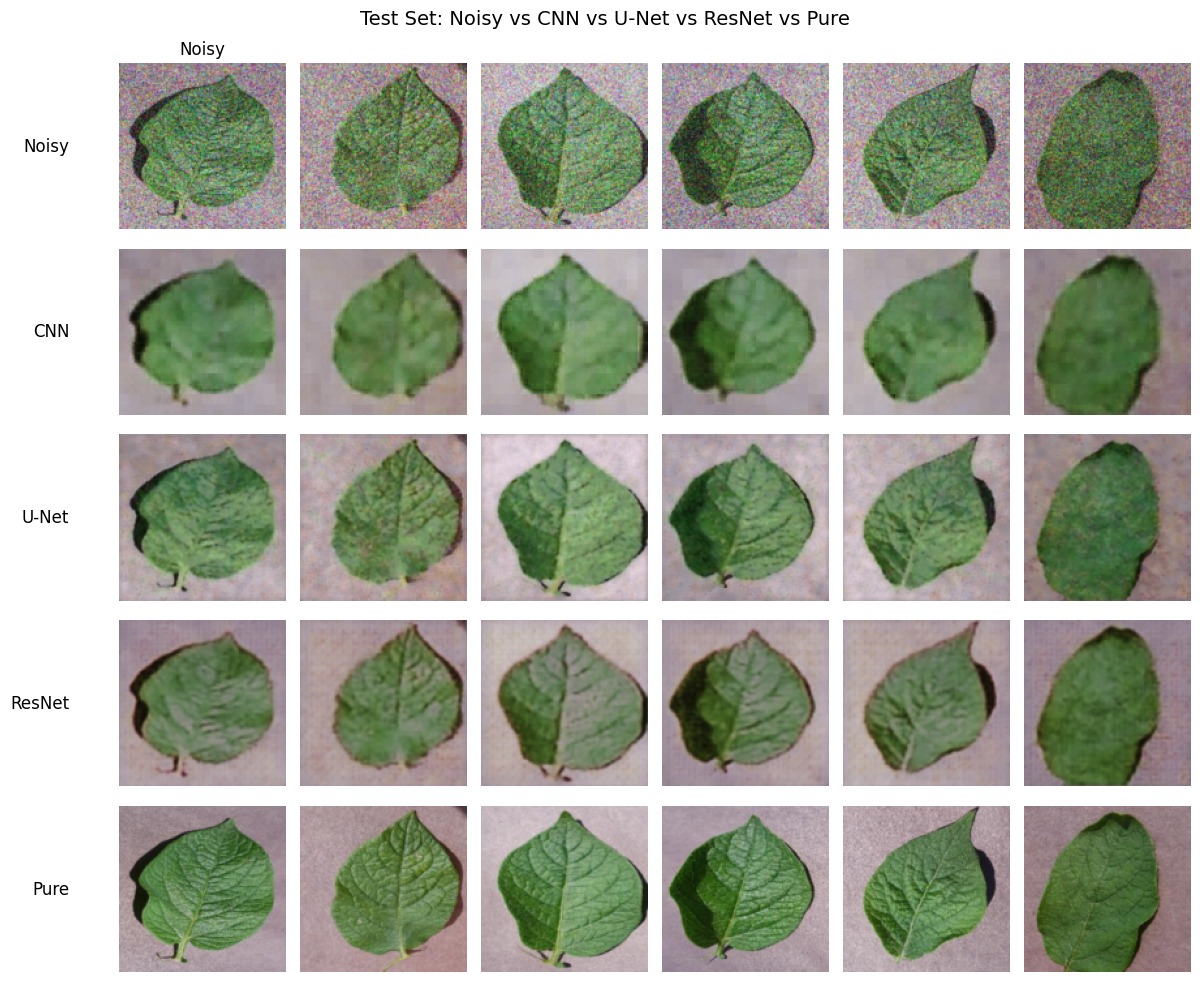

Summary:
  CNN Autoencoder  MSE=0.00270  PSNR=25.75 dB  SSIM=0.5966
  U-Net            MSE=0.00259  PSNR=26.00 dB  SSIM=0.7310
  ResNet           MSE=0.00299  PSNR=25.83 dB  SSIM=0.6924

Best model by test MSE: U-Net


In [25]:
# Side-by-side visual comparison: Noisy | CNN | U-Net | ResNet | Pure  (test set)
n = 6
noisy_imgs = cnn_last_batch[0][:n]
cnn_out = cnn_last_batch[1][:n]
unet_out = unet_last_batch[1][:n]
resnet_out = resnet_last_batch[1][:n]
pure_imgs = cnn_last_batch[2][:n]

rows = [("Noisy", noisy_imgs), ("CNN", cnn_out), ("U-Net", unet_out),
        ("ResNet", resnet_out), ("Pure", pure_imgs)]

fig, axes = plt.subplots(len(rows), n, figsize=(2 * n, 2 * len(rows)))
fig.suptitle('Test Set: Noisy vs CNN vs U-Net vs ResNet vs Pure', fontsize=14)

for r, (row_name, imgs) in enumerate(rows):
    for i in range(n):
        axes[r, i].imshow(imgs[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[r, i].axis('off')
        if i == 0:
            axes[r, i].set_ylabel(row_name)
            axes[r, i].set_title(row_name) if r == 0 else None
    axes[r, 0].set_title(row_name, loc='left') if False else None

# add row labels manually since axis('off') hides them
for r, (row_name, _) in enumerate(rows):
    axes[r, 0].text(-0.3, 0.5, row_name, transform=axes[r, 0].transAxes,
                     fontsize=12, va='center', ha='right')

plt.tight_layout()
plt.show()

print("Summary:")
for name, m in results.items():
    print(f"  {name:<16} MSE={m['MSE']:.5f}  PSNR={m['PSNR']:.2f} dB  SSIM={m['SSIM']:.4f}")
best_model = min(results, key=lambda k: results[k]['MSE'])
print(f"\nBest model by test MSE: {best_model}")